## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [1]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

Incorporamos MLFlow

In [2]:
import mlflow
import mlflow.sklearn
from datetime import datetime

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("13MBID-Experimentacion original (MVP modificado con Undersampling)")

<Experiment: artifact_location='file:c:/VIU_13MBID_AG1/13MBID/notebooks/mlruns/478327721300563060', creation_time=1776575144922, experiment_id='478327721300563060', last_update_time=1776575144922, lifecycle_stage='active', name='13MBID-Experimentacion original (MVP modificado con Undersampling)', tags={}>

In [3]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,edad,antiguedad_empleado,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,estado_credito,falta_pago,antiguedad_cliente,...,genero,limite_credito_tc,nivel_educativo,personas_a_cargo,capacidad_pago,operaciones_mensuales,presion_financiera,gasto_promedio_operacion,operaciones_mensuales_tc,estabilidad_laboral
0,22,123.0,ALQUILER,59000,PERSONAL,0.59,16.02,1,Y,36.0,...,M,4010.0,UNIVERSITARIO_COMPLETO,2.0,0.593220,2.000000,0.216181,45.333333,2.000000,5.590909
1,21,5.0,PROPIA,9600,EDUCACIÓN,0.10,11.14,0,N,39.0,...,M,12691.0,SECUNDARIO_COMPLETO,3.0,0.104167,3.500000,0.171250,27.238095,3.500000,0.238095
2,25,1.0,HIPOTECA,9600,SALUD,0.57,12.87,1,N,44.0,...,F,8256.0,UNIVERSITARIO_COMPLETO,5.0,0.572917,2.750000,0.325451,39.121212,2.750000,0.040000
3,23,4.0,ALQUILER,65500,SALUD,0.53,15.23,1,N,36.0,...,M,3418.0,UNIVERSITARIO_COMPLETO,3.0,0.534351,1.666667,0.295985,94.350000,1.666667,0.173913
4,24,8.0,ALQUILER,54400,SALUD,0.55,14.27,1,Y,54.0,...,M,9095.0,DESCONOCIDO,1.0,0.643382,2.166667,0.185000,50.538462,2.166667,0.333333


In [4]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

edad
antiguedad_empleado
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
estado_credito
falta_pago
antiguedad_cliente
estado_civil
estado_cliente
gastos_ult_12m
genero
limite_credito_tc
nivel_educativo
personas_a_cargo
capacidad_pago
operaciones_mensuales
presion_financiera
gasto_promedio_operacion
operaciones_mensuales_tc
estabilidad_laboral

Cantidad de filas: 10123


In [5]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (10123, 22)
Dimensiones y: (10123,)


In [6]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7105, 22)
Validation: (2005, 22)
Test: (1013, 22)


In [7]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['edad', 'antiguedad_empleado', 'ingresos', 'pct_ingreso', 'tasa_interes', 'estado_credito', 'antiguedad_cliente', 'gastos_ult_12m', 'limite_credito_tc', 'personas_a_cargo', 'capacidad_pago', 'operaciones_mensuales', 'presion_financiera', 'gasto_promedio_operacion', 'operaciones_mensuales_tc', 'estabilidad_laboral']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_civil', 'estado_cliente', 'genero', 'nivel_educativo']


In [8]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

falta_pago
N    5864
Y    1241
Name: count, dtype: int64

In [9]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [10]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8254364089775561


In [11]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    )
}

Versión Orignal

In [12]:
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.under_sampling import RandomUnderSampler
# from sklearn.model_selection import cross_validate
# #  Se evaluan los modelos con validación cruzada comparando sus resultados
# resultados = []

# for nombre, modelo in modelos.items():
#     # Se aplica el preprocesamiento
#     pipeline = ImbPipeline([
#         ("prep", preprocessor),
#         ("undersample", RandomUnderSampler(random_state = 42)),
#         ("model", modelo)
#     ])

#     # Se evalúan los modelos con validación cruzada
#     scores = cross_validate(
#         pipeline,
#         X_train,
#         y_train,
#         cv=5,
#         scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
#     )

#     # Se almacenan los resultados
#     resultados.append({
#         "modelo": nombre,
#         "accuracy": scores["test_accuracy"].mean(),
#         "precision": scores["test_precision"].mean(),
#         "recall": scores["test_recall"].mean(),
#         "f1": scores["test_f1"].mean(),
#         "roc_auc": scores["test_roc_auc"].mean(),
#      })

# df_resultados = pd.DataFrame(resultados)

# df_resultados.sort_values("roc_auc", ascending=False) 

Valor modificado al integrar MLFlow

In [13]:
# Se evaluan los modelos con validación cruzada comparando sus resultados
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
from mlflow.models import infer_signature
import numpy as np


# Función auxiliar para obtener un score continuo y poder calcular ROC AUC.
# Se prioriza `predict_proba` y, si el modelo no lo soporta, se usa `decision_function`.
def _score_for_auc(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return None

# Scorers personalizados para evitar métricas `NaN` cuando un modelo no predice
# la clase positiva en algún fold de validación cruzada.
def _cv_precision(estimator, X, y):
    return precision_score(y, estimator.predict(X), zero_division=0)

def _cv_recall(estimator, X, y):
    return recall_score(y, estimator.predict(X), zero_division=0)

def _cv_f1(estimator, X, y):
    return f1_score(y, estimator.predict(X), zero_division=0)

# Se convierte la variable objetivo una sola vez y fuera del loop.
# Cambio realizado: así se evita modificar `y_train`, `y_val` y `y_test`
# en cada iteración de modelos.
if set(y_train.dropna().unique()) == {"N", "Y"}:
    y_train_eval = y_train.map({"N": 0, "Y": 1})
    y_val_eval = y_val.map({"N": 0, "Y": 1})
    y_test_eval = y_test.map({"N": 0, "Y": 1})
else:
    y_train_eval = y_train.copy()
    y_val_eval = y_val.copy()
    y_test_eval = y_test.copy()


def evaluar_y_registrar_mlflow(nombre, modelo):
    # Se arma un pipeline con preprocesamiento, undersampling y el modelo a evaluar
    pipeline = ImbPipeline([
            ("prep", preprocessor),
            ("undersample", RandomUnderSampler(random_state=42)),
            ("model", modelo)
        ])

    # Se evalúan los modelos con validación cruzada
    # Cambio realizado: se usan scorers personalizados para precision, recall y f1,
    # evitando valores indefinidos en validación cruzada.
    scores = cross_validate(
        pipeline,
        X_train,
        y_train_eval, # Cambio realizado: se usa `y_train_eval` con valores numéricos para la evaluación.
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "precision": _cv_precision,
            "recall": _cv_recall,
            "f1": _cv_f1,
            "roc_auc": "roc_auc"
        }
    )

    # Se entrena el pipeline completo con todos los datos de entrenamiento.
    pipeline.fit(X_train, y_train_eval)

    # Predicciones y scores sobre test.
    y_test_pred = pipeline.predict(X_test)
    y_test_score = _score_for_auc(pipeline, X_test)
    test_roc_auc = roc_auc_score(y_test_eval, y_test_score) if y_test_score is not None else np.nan

    # Se infiere la firma del modelo para registrar correctamente en MLflow.
    signature = infer_signature(X_train, pipeline.predict(X_train))

    with mlflow.start_run(run_name=f"Evaluación {nombre}"):
        # Se registran los hiperparámetros del modelo.
        mlflow.log_params(modelo.get_params())

        # Se registran parámetros adicionales del experimento.
        mlflow.log_params({
            "train_samples": len(X_train),
            "validation_samples": len(X_val),
            "test_samples": len(X_test),
            "balancing_method": "undersampling",
            "cv_folds": 5
        })

        # Métricas promedio y desvío estándar de validación cruzada.
        mlflow.log_metrics({
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_precision_mean": scores["test_precision"].mean(),
            "cv_recall_mean": scores["test_recall"].mean(),
            "cv_f1_mean": scores["test_f1"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_precision_std": scores["test_precision"].std(),
            "cv_recall_std": scores["test_recall"].std(),
            "cv_f1_std": scores["test_f1"].std(),
            "cv_roc_auc_std": scores["test_roc_auc"].std()
        })

        mlflow.log_metrics({
            "test_accuracy": accuracy_score(y_test_eval, y_test_pred),
            "test_precision": precision_score(y_test_eval, y_test_pred, zero_division=0),
            "test_recall": recall_score(y_test_eval, y_test_pred, zero_division=0),
            "test_f1": f1_score(y_test_eval, y_test_pred, zero_division=0),
            "test_roc_auc": test_roc_auc
        })

        # Se registra el modelo entrenado en MLflow.
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            signature=signature
        )

        print(f"Modelo {nombre} evaluado y registrado en MLflow.")

        # Se devuelve un resumen para construir la tabla comparativa final.
    return {
        "modelo": nombre,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }


resultados = []

for nombre, modelo in modelos.items():
    resultados.append(evaluar_y_registrar_mlflow(nombre, modelo))

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("roc_auc", ascending=False)

Modelo LogisticRegression evaluado y registrado en MLflow.
Modelo LinearSVC evaluado y registrado en MLflow.
Modelo KNN evaluado y registrado en MLflow.
Modelo DecisionTree evaluado y registrado en MLflow.
Modelo RandomForest evaluado y registrado en MLflow.


,modelo,accuracy,precision,recall,f1,roc_auc
4,RandomForest,0.855032,0.554019,0.875891,0.678596,0.939343
0,LogisticRegression,0.846165,0.538351,0.847707,0.658379,0.923370
1,LinearSVC,0.847713,0.541813,0.841259,0.658972,0.922948
2,KNN,0.799437,0.458778,0.813088,0.586363,0.879991
3,DecisionTree,0.832794,0.514579,0.813072,0.630057,0.825019


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = ImbPipeline([
    ("prep", preprocessor),
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train_eval)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor ROC AUC:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': None}
Mejor ROC AUC: 0.9444580299712998


In [14]:
# Se entrena el mejor modelo

modelo_final = Pipeline([
    ("prep", preprocessor),
    # ("model", LinearSVC(max_iter=5000)) --- Original
    ("model", LogisticRegression(max_iter=2000))
])

modelo_final.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['edad',
                                                   'antiguedad_empleado',
                                                   'ingresos', 'pct_ingreso',
                                                   'tasa_interes',
                                                   'estado_credito',
                                                   'antiguedad_cliente',
                                                   'gastos_ult_12m',
                                                   'limite_credito_tc',
                                                   'personas_a_cargo',
                                                   'capacidad_pago',
                                                   'operaciones_mensuales',
                                                   'presion_financiera',
                                                   'gasto_promedio_operacion',
                                                   'operaciones_mensuales_tc',
                                                   'estabilidad_laboral']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['situacion_vivienda',
                                                   'objetivo_credito',
                                                   'estado_civil',
                                                   'estado_cliente', 'genero',
                                                   'nivel_educativo'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [15]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           N       0.92      0.95      0.93      1655
           Y       0.72      0.60      0.65       350

    accuracy                           0.89      2005
   macro avg       0.82      0.77      0.79      2005
weighted avg       0.88      0.89      0.88      2005



In [16]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           N       0.92      0.95      0.93       836
           Y       0.71      0.62      0.66       177

    accuracy                           0.89      1013
   macro avg       0.81      0.78      0.80      1013
weighted avg       0.88      0.89      0.89      1013



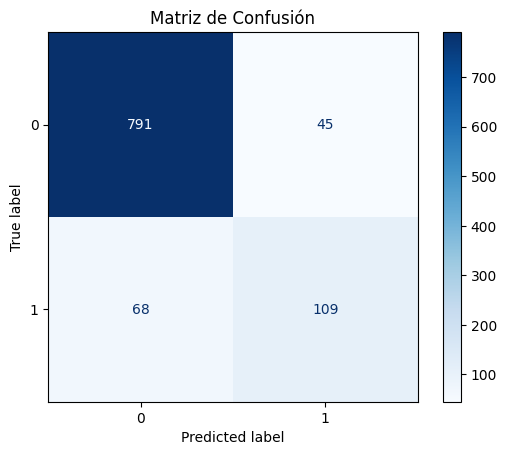

In [17]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()

In [18]:
df_resultados.to_csv("resultados_modelos.csv", index=False)